# RDD2022 Dataset Inspection

This notebook explores the raw RDD2022 annotations before any model training or label conversion.



In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET
from collections import Counter


# Finding all the classes that are present in our dataset along with their frequencies

root_dir = Path("../data/raw/RDD2022")
object_counts = Counter()

for country_dir in sorted(path for path in root_dir.iterdir() if path.is_dir()):
    xml_dir = country_dir / "train" / "annotations" / "xmls"

    if not xml_dir.exists():
        print(f"Annotation folder not found: {xml_dir}")
        continue

    for xml_file in xml_dir.glob("*.xml"):
        tree = ET.parse(xml_file)
        for obj in tree.findall(".//object"):
            name = obj.findtext("name")
            if name:
                object_counts[name.strip()] += 1

for name, count in sorted(object_counts.items()):
    print(f"{name} -> {count}")

Block crack -> 3
D00 -> 26016
D01 -> 179
D0w0 -> 1
D10 -> 11830
D11 -> 45
D20 -> 10617
D40 -> 6544
D43 -> 793
D44 -> 5057
D50 -> 3581
Repair -> 1046



NOTE: The final project focuses on the four official road-damage classes:
- D00 — Longitudinal Crack
- D10 — Transverse Crack
- D20 — Alligator Crack
- D40 — Pothole

Therefore all the classes except the ones above need to be filtered.

## Target-Class Distribution by Country

Count the four official RDD2022 classes separately for each country to understand class imbalance and geographic differences.


In [2]:
classes = ("D00", "D10", "D20", "D40")
country_counts = {country: Counter() for country in (
    "CHINA", "JAPAN", "USA", "INDIA", "CZECH", "NORWAY"
)}

for country_dir in (path for path in root_dir.iterdir() if path.is_dir()):
    folder_name = country_dir.name.lower().replace("_", "").replace(" ", "")

    if "china" in folder_name:
        country = "CHINA"
    elif "japan" in folder_name:
        country = "JAPAN"
    elif folder_name in ("unitedstates", "usa", "us"):
        country = "USA"
    elif "india" in folder_name:
        country = "INDIA"
    elif "czech" in folder_name:
        country = "CZECH"
    elif "norway" in folder_name:
        country = "NORWAY"
    else:
        continue

    xml_dirs = [
        path for path in country_dir.rglob("xmls")
        if path.is_dir() and path.parent.name == "annotations"
    ]

    for annotations_dir in xml_dirs:
        for xml_path in annotations_dir.glob("*.xml"):
            for annotation_object in ET.parse(xml_path).findall(".//object"):
                object_name = annotation_object.findtext("name", "").strip()
                if object_name in classes:
                    country_counts[country][object_name] += 1

for country, counts in country_counts.items():
    print(f"{country}: " + " | ".join(
        f"{class_name} -> {counts[class_name]}" for class_name in classes
    ))

CHINA: D00 -> 4104 | D10 -> 2359 | D20 -> 934 | D40 -> 321
JAPAN: D00 -> 4049 | D10 -> 3979 | D20 -> 6199 | D40 -> 2243
USA: D00 -> 6750 | D10 -> 3295 | D20 -> 834 | D40 -> 135
INDIA: D00 -> 1555 | D10 -> 68 | D20 -> 2021 | D40 -> 3187
CZECH: D00 -> 988 | D10 -> 399 | D20 -> 161 | D40 -> 197
NORWAY: D00 -> 8570 | D10 -> 1730 | D20 -> 468 | D40 -> 461


In [3]:
import pandas as pd

class_totals = pd.DataFrame.from_dict(country_counts, orient="index").reindex(
    index=["CHINA", "JAPAN", "USA", "INDIA", "CZECH", "NORWAY"],
    columns=classes,
    fill_value=0,
)

country_percentages = class_totals.div(class_totals.sum(axis=1), axis=0).mul(100)
country_percentages = country_percentages.round(2)

country_percentages

,D00,D10,D20,D40
CHINA,53.17,30.56,12.10,4.16
JAPAN,24.58,24.16,37.64,13.62
USA,61.29,29.92,7.57,1.23
INDIA,22.76,1.00,29.59,46.65
CZECH,56.62,22.87,9.23,11.29
NORWAY,76.32,15.41,4.17,4.11


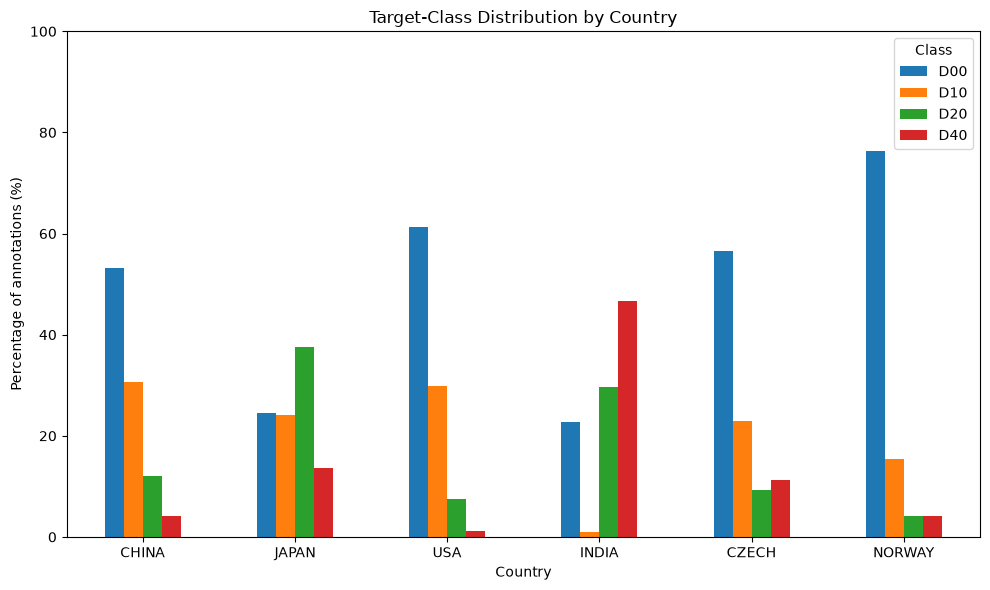

In [4]:
import matplotlib.pyplot as plt

ax = country_percentages.plot(kind="bar", figsize=(10, 6))
ax.set_xlabel("Country")
ax.set_ylabel("Percentage of annotations (%)")
ax.set_title("Target-Class Distribution by Country")
ax.set_ylim(0, 100)
ax.legend(title="Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Few thing that stand out from the data:
- India is unusually pothole-heavy: D40 ≈ 46.7%
- Norway is dominated by D00: ≈ 76.3%
- USA is also heavily D00: ≈ 61.3%
- Japan has much more D20 than the other countries: ≈ 37.6%

## Visual Annotation check

Randomly pick images for each target class and draw bounding boxes on them using the corresponding annotation to check if the annotations present in the dataset are correct.

D00: China_MotorBike_000595.xml | China_MotorBike_000595.jpg | coordinates=(185.0, 1.0, 206.0, 510.0)
D10: Japan_012606.xml | Japan_012606.jpg | coordinates=(411.0, 280.0, 600.0, 303.0)
D20: United_States_003943.xml | United_States_003943.jpg | coordinates=(288.0, 527.0, 412.0, 637.0)
D40: India_000392.xml | India_000392.jpg | coordinates=(222.0, 414.0, 294.0, 469.0)


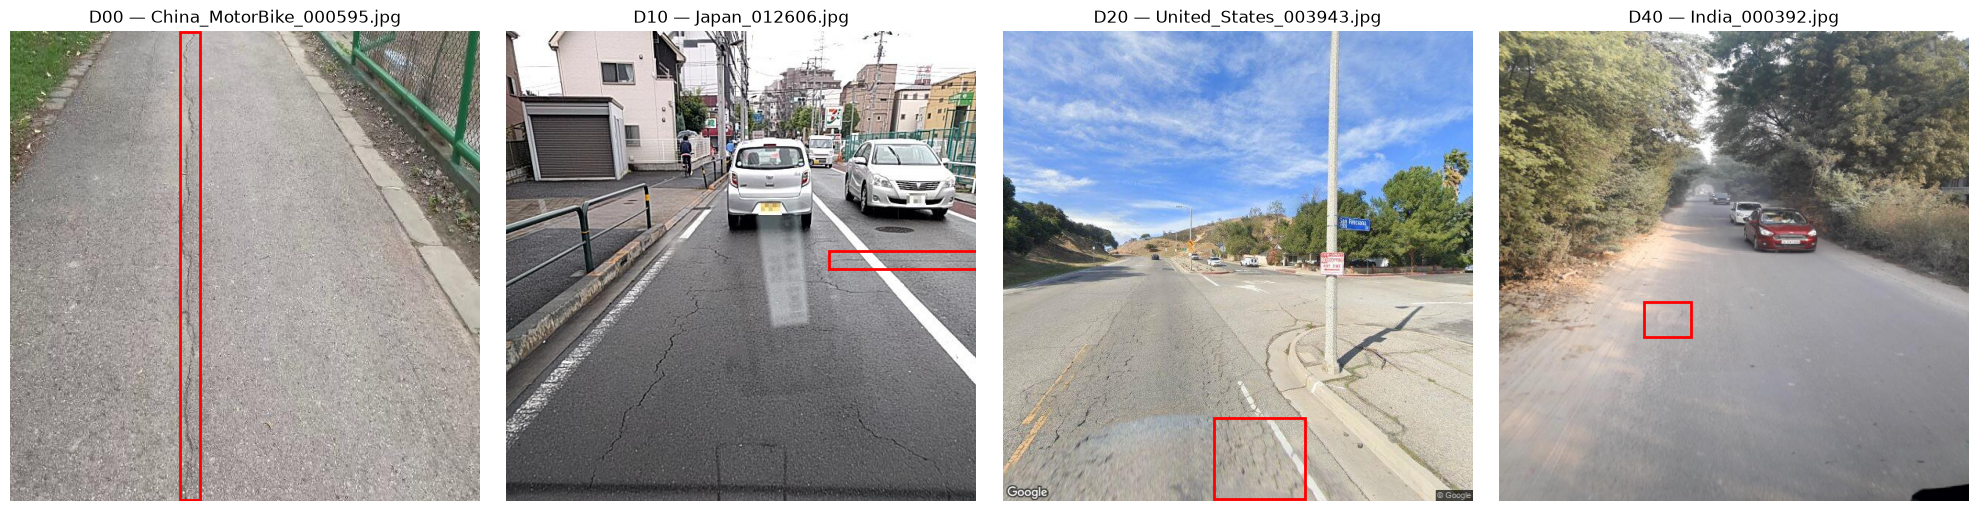

In [5]:
import random
from matplotlib.patches import Rectangle

rng = random.Random(465)
xml_files = sorted(root_dir.rglob("*.xml"))
rng.shuffle(xml_files)
image_extensions = {".jpg", ".jpeg", ".png"}

examples = {}

for xml_path in xml_files:
    image_dir = xml_path.parent.parent.parent / "images"
    image_path = next(
        (
            image_dir / f"{xml_path.stem}{extension}"
            for extension in sorted(image_extensions)
            if (image_dir / f"{xml_path.stem}{extension}").is_file()
        ),
        None,
    )
    if image_path is None:
        continue

    xml_root = ET.parse(xml_path).getroot()
    for obj in xml_root.findall(".//object"):
        label = obj.findtext("name", "").strip()
        if label not in classes or label in examples:
            continue

        box = obj.find("bndbox")
        if box is None:
            continue

        try:
            xmin, ymin, xmax, ymax = (
                float(box.findtext(coord)) for coord in ("xmin", "ymin", "xmax", "ymax")
            )
        except (TypeError, ValueError):
            continue

        examples[label] = (xml_path, image_path, xmin, ymin, xmax, ymax)

    if len(examples) == len(classes):
        break

missing = set(classes) - examples.keys()
if missing:
    raise FileNotFoundError(f"No matching XML/image examples found for: {sorted(missing)}")

fig, axes = plt.subplots(1, len(classes), figsize=(20, 5))

for ax, label in zip(axes, classes):
    xml_path, image_path, xmin, ymin, xmax, ymax = examples[label]
    image = plt.imread(image_path)
    ax.imshow(image)
    ax.add_patch(Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        edgecolor="red",
        linewidth=2,
    ))
    ax.set_title(f"{label} — {image_path.name}")
    ax.axis("off")
    print(f"{label}: {xml_path.name} | {image_path.name} | "
          f"coordinates=({xmin}, {ymin}, {xmax}, {ymax})")

plt.tight_layout()
plt.show()

## Bounding box validation

Make sure that all the bounding boxes in the data set have valid coordinates. <br> <br>
Test condition : <br>
0 <= xmin < xmax <= image width
0 <= ymin < ymax <= image height

In [6]:
from PIL import Image

invalid_box_count = 0
xml_count = 0

for xml_path in root_dir.rglob("*.xml"):
    xml_count += 1
    image_dir = xml_path.parents[2] / "images"

    image_path = next(
        (
            image_dir / f"{xml_path.stem}{extension}"
            for extension in image_extensions
            if (image_dir / f"{xml_path.stem}{extension}").is_file()
        ),
        None,
    )
    if image_path is None:
        raise FileNotFoundError(f"No matching image found for {xml_path}")

    with Image.open(image_path) as image_file:
        image_width, image_height = image_file.size

    for obj in ET.parse(xml_path).findall(".//object"):
        box = obj.find("bndbox")
        try:
            xmin, ymin, xmax, ymax = (
                float(box.findtext(coord))
                for coord in ("xmin", "ymin", "xmax", "ymax")
            ) if box is not None else (None, None, None, None)
        except (TypeError, ValueError):
            xmin, ymin, xmax, ymax = None, None, None, None

        if (
            xmin is None
            or not (0 <= xmin < xmax <= image_width)
            or not (0 <= ymin < ymax <= image_height)
        ):
            invalid_box_count += 1

print(f"XML files checked: {xml_count}")
print(f"Invalid Box: {invalid_box_count}")

XML files checked: 38385
Invalid Box: 1


NOTE: One invalid box was found , this will be skipped during yolo conversion

## Summary

The dataset looks ready for preprocessing.

- The project will use the four main classes: D00, D10, D20 and D40.
- The class distribution is quite different across countries, which should make the later generalization experiment interesting.
- A few annotations were checked visually and the bounding boxes looked correct.
- One invalid box was found. That box will simply be skipped during YOLO conversion.
- The raw dataset will be kept unchanged and all preprocessing will be done separately.